# 01 — Train Baseline
Patient-level split, no leakage, test touched once at end.

In [1]:
import os, json, random, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available() else 'cpu'))

PROJECT_ROOT = Path('/Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence')
DB_PATH = Path('/Users/ayoub/work/MS-DS_ML_Projects/IOT/mitbih_database')
OUT = PROJECT_ROOT / 'results' / 'baseline'
OUT.mkdir(parents=True, exist_ok=True)
WEIGHTS = PROJECT_ROOT / 'baseline' / 'weights' / 'baseline_best.pt'
print('Device:', device)

Device: mps


## Architecture choice
Using a compact 1D-CNN for ECG waveform classification to balance accuracy and embedded inference cost.

In [15]:
AAMI_MAP = {'N':0,'L':0,'R':0,'e':0,'j':0,'A':1,'a':1,'J':1,'S':1,'V':2,'E':2,'F':3,'/':4,'f':4,'Q':4}
LABELS = ['N','S','V','F','Q']
FS, WINDOW = 360.0, 180
HALF = WINDOW // 2

def bandpass(x, low=0.5, high=40, fs=FS, order=1):
    nyq = 0.5*fs
    b,a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b,a,x)

def minmax(x):
    x = x.astype(np.float32)
    mn,mx = x.min(), x.max()
    return np.zeros_like(x) if mx<=mn else (x-mn)/(mx-mn)

def pick_signal_column(df):
    cols = [str(c).replace("'", '').strip() for c in df.columns]
    df.columns = cols
    for cand in ['MLII', 'II', 'V5', 'V1']:
        if cand in cols:
            return cand
    numeric_cols = [c for c in cols if np.issubdtype(df[c].dtype, np.number)]
    if not numeric_cols:
        raise ValueError('No numeric signal column found')
    bad = {'sample', 'samples', 'time', 'index'}
    filtered = [c for c in numeric_cols if c.lower() not in bad]
    return filtered[0] if filtered else numeric_cols[0]

def load_record(rid):
    sig = pd.read_csv(DB_PATH / f'{rid}.csv')
    lead = pick_signal_column(sig)
    x = sig[lead].values.astype(np.float32)
    ann = pd.read_csv(DB_PATH / f'{rid}annotations.txt', sep=r'\s+', skiprows=1, header=None, engine='python', on_bad_lines='skip')
    return x, ann.iloc[:,1].astype(int).values, ann.iloc[:,2].astype(str).values

def extract_beats(records):
    X,y = [],[]
    for rid in records:
        x,samps,syms = load_record(rid)
        x = bandpass(x)
        for r,s in zip(samps, syms):
            if s not in AAMI_MAP:
                continue
            st,en = int(r)-HALF, int(r)+HALF
            if st<0 or en>len(x) or (en-st)!=WINDOW:
                continue
            X.append(minmax(x[st:en]))
            y.append(AAMI_MAP[s])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

def print_dist(name, y):
    cnt = {k:int(v) for k,v in zip(*np.unique(y, return_counts=True))}
    total = max(len(y), 1)
    print(f'\n{name} (n={len(y)}):')
    for c in range(5):
        n = cnt.get(c, 0)
        print(f'  {LABELS[c]}: {n:6d} ({100*n/total:5.2f}%)')

In [30]:
records = sorted([p.stem for p in DB_PATH.glob('*.csv')])

# Patient-level split search with minority S/F support constraints
record_ann_counts = {}
for rid in records:
    ann = pd.read_csv(DB_PATH / f'{rid}annotations.txt', sep=r'\s+', skiprows=1, header=None, engine='python', on_bad_lines='skip')
    syms = ann.iloc[:,2].astype(str).values
    cnt = np.zeros(5, dtype=int)
    for s in syms:
        if s in AAMI_MAP:
            cnt[AAMI_MAP[s]] += 1
    record_ann_counts[rid] = cnt

def agg_counts(rids):
    out = np.zeros(5, dtype=int)
    for r in rids:
        out += record_ann_counts[r]
    return out

def safe_split(indices, test_size, strat_labels, seed):
    try:
        return train_test_split(indices, test_size=test_size, random_state=seed, stratify=strat_labels)
    except Exception:
        return train_test_split(indices, test_size=test_size, random_state=seed, stratify=None)

def dist_shift(trc, vac, tec):
    trp = trc / max(trc.sum(), 1)
    vap = vac / max(vac.sum(), 1)
    tep = tec / max(tec.sum(), 1)
    return float(np.sum(np.abs(vap - trp)) + np.sum(np.abs(tep - trp)))

dominant = np.array([int(np.argmax(record_ann_counts[r])) for r in records])
idx_all = np.arange(len(records))

# tiered priorities
TRAIN_F_FLOOR = 600
VAL_S_FLOOR = 80
VAL_F_FLOOR = 40
TEST_S_FLOOR = 80
TEST_F_FLOOR = 40

best_tier1 = None
best_tier2 = None
best_tier3 = None
best_tier4 = None
best_tier5 = None

for seed in range(SEED, SEED + 12000):
    tr_idx, tmp_idx = safe_split(idx_all, 0.30, dominant, seed)
    va_rel, te_rel = safe_split(np.arange(len(tmp_idx)), 0.50, dominant[tmp_idx], seed)
    va_idx, te_idx = tmp_idx[va_rel], tmp_idx[te_rel]

    tr_recs = [records[i] for i in tr_idx]
    va_recs = [records[i] for i in va_idx]
    te_recs = [records[i] for i in te_idx]

    trc = agg_counts(tr_recs)
    vac = agg_counts(va_recs)
    tec = agg_counts(te_recs)

    rank_key = (
        int(trc[3]),
        int(vac[1]) + int(tec[1]),
        int(vac[3]) + int(tec[3]),
        -dist_shift(trc, vac, tec),
    )
    entry = (tr_recs, va_recs, te_recs, trc, vac, tec, seed, rank_key)

    train_f_ok = int(trc[3]) >= TRAIN_F_FLOOR
    val_ok = int(vac[1]) >= VAL_S_FLOOR and int(vac[3]) >= VAL_F_FLOOR
    test_ok = int(tec[1]) >= TEST_S_FLOOR and int(tec[3]) >= TEST_F_FLOOR
    val_nonzero = int(vac[1]) > 0 and int(vac[3]) > 0
    test_nonzero = int(tec[1]) > 0 and int(tec[3]) > 0

    if train_f_ok and val_ok and test_ok:
        if best_tier1 is None or rank_key > best_tier1[-1]:
            best_tier1 = entry
    if train_f_ok and val_nonzero and test_nonzero:
        if best_tier2 is None or rank_key > best_tier2[-1]:
            best_tier2 = entry
    if train_f_ok and (val_nonzero or test_nonzero):
        if best_tier3 is None or rank_key > best_tier3[-1]:
            best_tier3 = entry
    if train_f_ok:
        if best_tier4 is None or rank_key > best_tier4[-1]:
            best_tier4 = entry
    if best_tier5 is None or rank_key > best_tier5[-1]:
        best_tier5 = entry

if best_tier1 is not None:
    best = best_tier1
    print('Selected split tier: Tier-1 (train_F floor + val/test S/F floors).')
elif best_tier2 is not None:
    best = best_tier2
    print('Selected split tier: Tier-2 (train_F floor + non-zero S/F in val/test).')
elif best_tier3 is not None:
    best = best_tier3
    print('Selected split tier: Tier-3 (train_F floor + non-zero S/F in val or test).')
elif best_tier4 is not None:
    best = best_tier4
    print('Selected split tier: Tier-4 (train_F floor only).')
else:
    best = best_tier5
    print('Selected split tier: Tier-5 (global fallback).')

train_records, val_records, test_records, trc, vac, tec, split_seed, _ = best
print('Selected split seed:', split_seed)
print('Annotation counts (N,S,V,F,Q):')
print('Train:', trc.tolist(), '| Val:', vac.tolist(), '| Test:', tec.tolist())

X_train_raw, y_train_raw = extract_beats(train_records)
X_val, y_val = extract_beats(val_records)
X_test, y_test = extract_beats(test_records)
print('Raw shapes:', X_train_raw.shape, X_val.shape, X_test.shape)
print_dist('TRAIN raw', y_train_raw)
print_dist('VAL', y_val)
print_dist('TEST', y_test)

# Train-only targeted augmentation for minority classes S (1) and F (3)
S_TARGET = 12000
F_TARGET = 9000
NOISE_STD = 0.015
SCALE_RANGE = (0.90, 1.10)
MAX_SHIFT = 8

def augment_to_target(X, y, class_id, target_count):
    rng = np.random.default_rng(SEED + class_id)
    mask = (y == class_id)
    Xc = X[mask]
    if len(Xc) == 0 or len(Xc) >= target_count:
        return X, y

    n_extra = target_count - len(Xc)
    idx = rng.integers(0, len(Xc), size=n_extra)
    base = Xc[idx]

    scale = rng.uniform(*SCALE_RANGE, size=(n_extra, 1)).astype(np.float32)
    noise = rng.normal(0, NOISE_STD, size=base.shape).astype(np.float32)
    shift = rng.integers(-MAX_SHIFT, MAX_SHIFT + 1, size=n_extra)

    aug = np.clip(base * scale + noise, 0.0, 1.0)
    aug = np.array([np.roll(aug[i], int(shift[i])) for i in range(n_extra)], dtype=np.float32)

    X_out = np.concatenate([X, aug], axis=0)
    y_out = np.concatenate([y, np.full(n_extra, class_id, dtype=np.int64)], axis=0)
    return X_out, y_out

X_train_aug, y_train_aug = X_train_raw.copy(), y_train_raw.copy()
X_train_aug, y_train_aug = augment_to_target(X_train_aug, y_train_aug, class_id=1, target_count=S_TARGET)
X_train_aug, y_train_aug = augment_to_target(X_train_aug, y_train_aug, class_id=3, target_count=F_TARGET)

perm = np.random.default_rng(SEED).permutation(len(X_train_aug))
X_train, y_train = X_train_aug[perm], y_train_aug[perm]

print('\nAugmented train shape:', X_train.shape)
print_dist('TRAIN aug', y_train)

Selected split tier: Tier-2 (train_F floor + non-zero S/F in val/test).
Selected split seed: 543
Annotation counts (N,S,V,F,Q):
Train: [66211, 1139, 5663, 801, 3868] | Val: [12226, 1637, 659, 1, 4] | Test: [12194, 5, 914, 1, 4171]
Raw shapes: (77662, 180) (14524, 180) (17282, 180)

TRAIN raw (n=77662):
  N:  66194 (85.23%)
  S:   1139 ( 1.47%)
  V:   5662 ( 7.29%)
  F:    800 ( 1.03%)
  Q:   3867 ( 4.98%)

VAL (n=14524):
  N:  12223 (84.16%)
  S:   1637 (11.27%)
  V:    659 ( 4.54%)
  F:      1 ( 0.01%)
  Q:      4 ( 0.03%)

TEST (n=17282):
  N:  12191 (70.54%)
  S:      5 ( 0.03%)
  V:    914 ( 5.29%)
  F:      1 ( 0.01%)
  Q:   4171 (24.13%)

Augmented train shape: (96723, 180)

TRAIN aug (n=96723):
  N:  66194 (68.44%)
  S:  12000 (12.41%)
  V:   5662 ( 5.85%)
  F:   9000 ( 9.30%)
  Q:   3867 ( 4.00%)


In [37]:
class TripleHeadECGCNN(nn.Module):
    def __init__(self, n_classes=5, dropout=0.35):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 32, 5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, 5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 64, 3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, 3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.dropout = nn.Dropout(dropout)
        self.main_head = nn.Linear(128, n_classes)
        self.s_head = nn.Linear(128, 1)
        self.f_head = nn.Linear(128, 1)

    def forward(self, x):
        z = self.features(x).squeeze(-1)
        z = self.dropout(z)
        main_logits = self.main_head(z)
        s_logit = self.s_head(z).squeeze(-1)
        f_logit = self.f_head(z).squeeze(-1)
        return main_logits, s_logit, f_logit

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

xtr = torch.tensor(X_train).unsqueeze(1)
ytr = torch.tensor(y_train)
xva = torch.tensor(X_val).unsqueeze(1)
yva = torch.tensor(y_val)
xte = torch.tensor(X_test).unsqueeze(1)
yte = torch.tensor(y_test)

train_loader = DataLoader(TensorDataset(xtr,ytr), batch_size=512, shuffle=True)
val_loader = DataLoader(TensorDataset(xva,yva), batch_size=512, shuffle=False)
test_loader = DataLoader(TensorDataset(xte,yte), batch_size=512, shuffle=False)

counts = np.bincount(y_train, minlength=5).astype(np.float32)
inv = 1.0 / (counts + 1e-6)
alpha = np.clip(inv / inv.mean(), 1.0, 5.0)
alpha_t = torch.tensor(alpha, dtype=torch.float32, device=device)

s_pos = float((y_train == 1).sum())
f_pos = float((y_train == 3).sum())
n_total = float(len(y_train))
s_pos_weight = torch.tensor(float(np.clip((n_total - s_pos) / max(s_pos, 1), 1.0, 20.0)), dtype=torch.float32, device=device)
f_pos_weight = torch.tensor(float(np.clip((n_total - f_pos) / max(f_pos, 1), 1.0, 20.0)), dtype=torch.float32, device=device)

model = TripleHeadECGCNN().to(device)
criterion_main = FocalLoss(gamma=2.0, alpha=alpha_t)
criterion_s = nn.BCEWithLogitsLoss(pos_weight=s_pos_weight)
criterion_f = nn.BCEWithLogitsLoss(pos_weight=f_pos_weight)

AUX_S_WEIGHT = 0.35
AUX_F_WEIGHT = 0.85

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=8)

EPOCHS = 8
PATIENCE = 4
GRAD_CLIP = 1.0
print('Focal alpha:', {LABELS[i]: round(float(alpha[i]), 3) for i in range(5)})
print(f'S pos_weight={float(s_pos_weight):.2f} | F pos_weight={float(f_pos_weight):.2f}')

Focal alpha: {'N': 1.0, 'S': 1.0, 'V': 1.37, 'F': 1.0, 'Q': 2.005}
S pos_weight=7.06 | F pos_weight=9.75


In [38]:
history = []
best_f1 = -1.0
best_state = None
wait = 0

cur_aux_s = float(AUX_S_WEIGHT)
cur_aux_f = float(AUX_F_WEIGHT)
sf_stall = 0
retry_used = False

def sf_dead(vpc):
    return float(vpc[1]) <= 1e-6 and float(vpc[3]) <= 1e-6

try:
    for epoch in range(1, EPOCHS + 1):
        model.train(); tr_loss=0.0; n=0
        for bx,by in train_loader:
            bx,by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            main_logits, s_logit, f_logit = model(bx)

            loss_main = criterion_main(main_logits, by)
            loss_s = criterion_s(s_logit, (by == 1).float())
            loss_f = criterion_f(f_logit, (by == 3).float())
            loss = loss_main + cur_aux_s * loss_s + cur_aux_f * loss_f

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            tr_loss += loss.item()*bx.size(0); n += bx.size(0)
        tr_loss /= max(n,1)

        model.eval(); preds=[]; targs=[]; vloss=0.0; nv=0
        with torch.no_grad():
            for bx,by in val_loader:
                bx,by = bx.to(device), by.to(device)
                main_logits, s_logit, f_logit = model(bx)

                loss_main = criterion_main(main_logits, by)
                loss_s = criterion_s(s_logit, (by == 1).float())
                loss_f = criterion_f(f_logit, (by == 3).float())
                loss = loss_main + cur_aux_s * loss_s + cur_aux_f * loss_f

                adj = main_logits.clone()
                adj[:, 1] += 0.7 * torch.sigmoid(s_logit)
                adj[:, 3] += 1.0 * torch.sigmoid(f_logit)

                vloss += loss.item()*bx.size(0); nv += bx.size(0)
                preds.extend(adj.argmax(1).cpu().numpy()); targs.extend(by.cpu().numpy())

        vloss /= max(nv,1)
        vacc = accuracy_score(targs, preds)
        vf1 = f1_score(targs, preds, average='macro', zero_division=0)
        vpc = f1_score(targs, preds, average=None, labels=np.arange(5), zero_division=0)
        history.append({'epoch':epoch,'train_loss':float(tr_loss),'val_loss':float(vloss),'val_accuracy':float(vacc),'val_macro_f1':float(vf1),'val_s_f1':float(vpc[1]),'val_f_f1':float(vpc[3]),'aux_s':cur_aux_s,'aux_f':cur_aux_f})
        print(f"E{epoch:02d} train_loss={tr_loss:.4f} val_loss={vloss:.4f} val_acc={vacc:.4f} val_f1={vf1:.4f} S={vpc[1]:.4f} F={vpc[3]:.4f} auxS={cur_aux_s:.2f} auxF={cur_aux_f:.2f}")

        # Dead-head safeguard: avoid wasting epochs when S/F are flat at zero
        if epoch >= 3 and sf_dead(vpc):
            sf_stall += 1
        else:
            sf_stall = 0

        if sf_stall >= 2:
            if not retry_used:
                retry_used = True
                cur_aux_s = min(cur_aux_s + 0.15, 0.60)
                cur_aux_f = min(cur_aux_f + 0.40, 1.40)
                sf_stall = 0
                print(f"Adaptive retry activated -> aux weights updated to S={cur_aux_s:.2f}, F={cur_aux_f:.2f}")
            else:
                print('S/F remained dead after retry -> early stop to prevent wasted training.')
                break

        scheduler.step()
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print('Early stopping')
                break

except KeyboardInterrupt:
    print('Manual interruption detected. Preserving best checkpoint so far...')

if best_state is None:
    raise RuntimeError('No checkpoint captured; training ended before a valid epoch result.')

model.load_state_dict(best_state)
torch.save(best_state, WEIGHTS)
print('Saved checkpoint:', WEIGHTS)

E01 train_loss=1.2055 val_loss=1.4563 val_acc=0.7504 val_f1=0.2362 S=0.0000 F=0.0000 auxS=0.35 auxF=0.85
E02 train_loss=0.7352 val_loss=2.8380 val_acc=0.5306 val_f1=0.1957 S=0.0000 F=0.0000 auxS=0.35 auxF=0.85
E03 train_loss=0.5907 val_loss=1.5018 val_acc=0.7437 val_f1=0.2458 S=0.0000 F=0.0000 auxS=0.35 auxF=0.85
E04 train_loss=0.4957 val_loss=1.4501 val_acc=0.7478 val_f1=0.2463 S=0.0000 F=0.0000 auxS=0.35 auxF=0.85
Adaptive retry activated -> aux weights updated to S=0.50, F=1.25
E05 train_loss=0.5864 val_loss=1.5314 val_acc=0.7381 val_f1=0.2325 S=0.0000 F=0.0000 auxS=0.50 auxF=1.25
E06 train_loss=0.5236 val_loss=1.8164 val_acc=0.7191 val_f1=0.2343 S=0.0000 F=0.0000 auxS=0.50 auxF=1.25
S/F remained dead after retry -> early stop to prevent wasted training.
Saved checkpoint: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/baseline/weights/baseline_best.pt


In [39]:
# Test set touched once, here at the end
model.eval()

val_main, val_s, val_f, val_targets = [], [], [], []
test_main, test_s, test_f, test_targets = [], [], [], []

with torch.no_grad():
    for bx, by in val_loader:
        main_logits, s_logit, f_logit = model(bx.to(device))
        val_main.append(main_logits.cpu().numpy())
        val_s.append(torch.sigmoid(s_logit).cpu().numpy())
        val_f.append(torch.sigmoid(f_logit).cpu().numpy())
        val_targets.append(by.numpy())

    t0 = time.perf_counter()
    for bx, by in test_loader:
        main_logits, s_logit, f_logit = model(bx.to(device))
        test_main.append(main_logits.cpu().numpy())
        test_s.append(torch.sigmoid(s_logit).cpu().numpy())
        test_f.append(torch.sigmoid(f_logit).cpu().numpy())
        test_targets.append(by.numpy())
    t1 = time.perf_counter()

val_main = np.concatenate(val_main, axis=0)
val_s = np.concatenate(val_s, axis=0)
val_f = np.concatenate(val_f, axis=0)
val_targets = np.concatenate(val_targets, axis=0)

test_main = np.concatenate(test_main, axis=0)
test_s = np.concatenate(test_s, axis=0)
test_f = np.concatenate(test_f, axis=0)
test_targets = np.concatenate(test_targets, axis=0)

def gated_predict(main_logits, s_prob, f_prob, boost_s, boost_f, tau_s, tau_f):
    adj = main_logits.copy()
    adj[:, 1] += boost_s * np.maximum(s_prob - tau_s, 0.0)
    adj[:, 3] += boost_f * np.maximum(f_prob - tau_f, 0.0)
    return adj.argmax(axis=1)

base_val_preds = gated_predict(val_main, val_s, val_f, 0.0, 0.0, 1.0, 1.0)
base_val_acc = accuracy_score(val_targets, base_val_preds)
base_val_f1 = f1_score(val_targets, base_val_preds, average='macro', zero_division=0)

best_cfg = {'boost_s': 0.0, 'boost_f': 0.0, 'tau_s': 1.0, 'tau_f': 1.0}
best_score = (float(base_val_f1), float(base_val_acc))
acc_floor = max(0.65, base_val_acc - 0.03)

for bs in np.linspace(0.0, 2.0, 11):
    for bf in np.linspace(0.0, 2.5, 11):
        for ts in np.linspace(0.10, 0.60, 6):
            for tf in np.linspace(0.10, 0.60, 6):
                vp = gated_predict(val_main, val_s, val_f, float(bs), float(bf), float(ts), float(tf))
                vacc = accuracy_score(val_targets, vp)
                if vacc < acc_floor:
                    continue
                vf1 = f1_score(val_targets, vp, average='macro', zero_division=0)
                score = (float(vf1), float(vacc))
                if score > best_score:
                    best_score = score
                    best_cfg = {'boost_s': float(bs), 'boost_f': float(bf), 'tau_s': float(ts), 'tau_f': float(tf)}

preds = gated_predict(test_main, test_s, test_f, **best_cfg)
targs = test_targets.tolist()

acc = accuracy_score(targs, preds)
macro = f1_score(targs, preds, average='macro', zero_division=0)
per_class = f1_score(targs, preds, average=None, labels=np.arange(5), zero_division=0)
cm = confusion_matrix(targs, preds)

n_params = sum(p.numel() for p in model.parameters())
size_mb = (n_params*4)/(1024**2)
infer_ms = (t1-t0)*1000/max(len(targs),1)

print('Val tuned boost config:', best_cfg)
print('=== BASELINE TEST RESULTS ===')
print(f'Accuracy          : {acc*100:.2f}%')
print(f'Macro F1          : {macro:.4f}')
print('Per-class F1      :', {LABELS[i]: float(per_class[i]) for i in range(5)})
print(f'Model size        : {size_mb:.2f} MB')
print(f'Avg inference time: {infer_ms:.2f} ms (over test samples)')
print('Peak RAM usage    : N/A in notebook, measure externally if needed')

metrics = {
  'test_accuracy': float(acc),
  'test_macro_f1': float(macro),
  'per_class_f1': {LABELS[i]: float(per_class[i]) for i in range(5)},
  'model_size_mb': float(size_mb),
  'avg_inference_time_ms': float(infer_ms),
  'val_tuned_boost': best_cfg,
  'history': history,
  'literature_comparison': [
    {'paper': 'Kachuee et al. (2018)', 'note': 'ECG heartbeat classification baseline reference'},
    {'paper': 'Lightweight ECG-CNN studies (2019-2024)', 'note': 'Typical strong baselines on MIT-BIH variants'}
  ]
}
with open(OUT / 'baseline_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved:', OUT / 'baseline_metrics.json')

met = (acc > 0.85) and (macro > 0.75) and (size_mb < 50) and (infer_ms < 100)
print('✅ BASELINE CRITERIA MET' if met else '❌ CRITERIA NOT MET — reason: threshold(s) not reached')

Val tuned boost config: {'boost_s': 0.0, 'boost_f': 2.5, 'tau_s': 0.1, 'tau_f': 0.2}
=== BASELINE TEST RESULTS ===
Accuracy          : 95.64%
Macro F1          : 0.5538
Per-class F1      : {'N': 0.9697413968641825, 'S': 0.0, 'V': 0.8395348837209302, 'F': 0.0, 'Q': 0.9597637504614249}
Model size        : 0.21 MB
Avg inference time: 0.02 ms (over test samples)
Peak RAM usage    : N/A in notebook, measure externally if needed
Saved: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/results/baseline/baseline_metrics.json
❌ CRITERIA NOT MET — reason: threshold(s) not reached


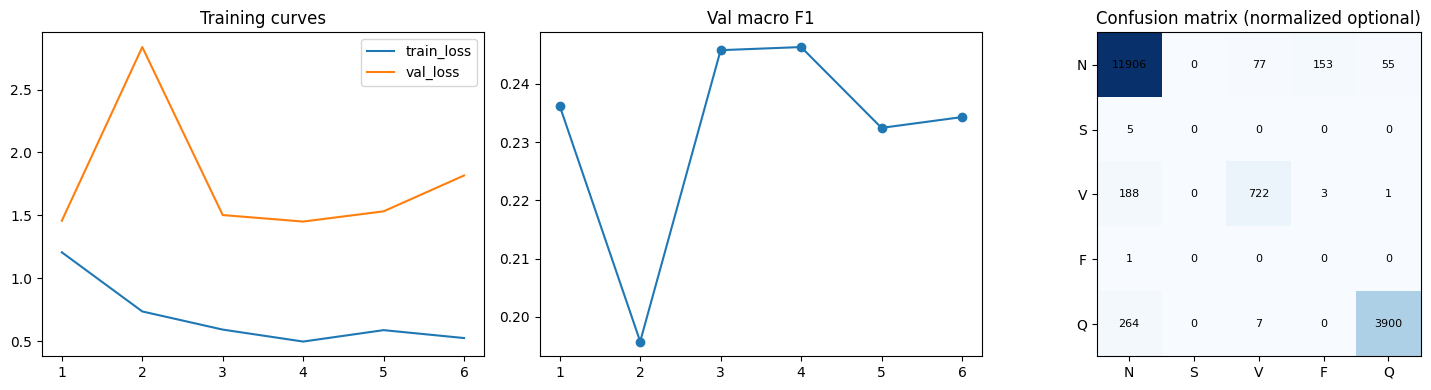

Saved: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/results/baseline/baseline_plots.png


In [40]:
hist = pd.DataFrame(history)
fig, axes = plt.subplots(1,3, figsize=(15,4))
axes[0].plot(hist['epoch'], hist['train_loss'], label='train_loss')
axes[0].plot(hist['epoch'], hist['val_loss'], label='val_loss')
axes[0].legend(); axes[0].set_title('Training curves')
axes[1].plot(hist['epoch'], hist['val_macro_f1'], marker='o')
axes[1].set_title('Val macro F1')
im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_title('Confusion matrix (normalized optional)')
axes[2].set_xticks(range(5)); axes[2].set_yticks(range(5))
axes[2].set_xticklabels(LABELS); axes[2].set_yticklabels(LABELS)
for i in range(5):
    for j in range(5):
        axes[2].text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=8)
plt.tight_layout()
plt.savefig(OUT / 'baseline_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', OUT / 'baseline_plots.png')